In [10]:
import sys
sys.path.append("..")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Data preprocessing

## Import data and join tables

### Functions

In [12]:
def import_data():
    conditions = pd.read_csv('../raw_data/Conditions.txt', sep='\t')
    experiment_conditions = pd.read_csv('../raw_data/ExperimentConditions.txt', sep='\t')
    experiments = pd.read_csv('../raw_data/Experiments.txt', sep='\t', encoding='latin1')
    logcs = pd.read_csv('../raw_data/LogCs.txt', sep='\t')
    properties = pd.read_csv('../raw_data/Properties.txt', sep='\t')
    response_properties = pd.read_csv('../raw_data/ResponseProperties.txt', sep='\t')
    responses = pd.read_csv('../raw_data/Responses.txt', sep='\t', encoding='latin1')
    source = pd.read_csv('../raw_data/Source.txt', sep='\t')

    return conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source

In [13]:
# This function is not needed since the column TObs is already present in the
# logcs dataframe. Anyway, this is part of the cleaning process, in the next
# part of the notebook
def remove_data_points(df, time_threshold=1000):
    # If we want to remove data points where the maximum time exceeds a certain
    # treshold
    max_time = df.groupby('ResponseID', as_index=False).max('Time')
    include = max_time.loc[max_time['Time'] <= time_threshold]['ResponseID'].tolist()
    filtered_df = df[df['ResponseID'].isin(include)]

    return filtered_df

In [14]:
def merge_data(conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source):
    # Pivot ExperimentConditions table to have one row per ExperimentID before the merge
    # This table is not needed for the actual project, but will be useful for us
    # in the future...
    # experiment_conditions_pivot = experiment_conditions.pivot_table(index='ExperimentID', columns='ConditionID', values='Value').reset_index()

    # Merge the tables to create a single DataFrame for analysis. Will join data based on the logcs table
    data = responses.merge(experiments, left_on='ExperimentID', right_on='ID',
                           how='left'
                           ).drop(columns=['ID_y']
                                  ).rename(columns={'ID_x': 'ResponseID'})
    # data = data.merge(experiment_conditions_pivot, on='ExperimentID', how='left')
    data = data.merge(response_properties, on='ResponseID', how='left'
                      ).rename(columns={'Value_x': 'ResponseValue',
                                        'Value_y': 'ResponsePropertiesValue'})
    data = data.merge(logcs, on='ResponseID', how='right')

    return data

### Explanations behind the functions...

In [15]:
# Import tables from the raw data directory
conditions = pd.read_csv('../raw_data/Conditions.txt', sep='\t')
experiment_conditions = pd.read_csv('../raw_data/ExperimentConditions.txt', sep='\t')
experiments = pd.read_csv('../raw_data/Experiments.txt', sep='\t', encoding='latin1')
logcs = pd.read_csv('../raw_data/LogCs.txt', sep='\t')
properties = pd.read_csv('../raw_data/Properties.txt', sep='\t')
response_properties = pd.read_csv('../raw_data/ResponseProperties.txt', sep='\t')
responses = pd.read_csv('../raw_data/Responses.txt', sep='\t', encoding='latin1')
source = pd.read_csv('../raw_data/Source.txt', sep='\t')

In [16]:
# Transform the LogCs table to have one row per ResponseID with a dictionay
logcs_dict = logcs.groupby('ResponseID').apply(
    lambda x: dict(zip(x['Time'], x['Value']))
).reset_index()

/tmp/ipykernel_5047/4111049196.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  logcs_dict = logcs.groupby('ResponseID').apply(


In [17]:
# Pivot ExperimentConditions table to have one row per ExperimentID before the merge
experiment_conditions_pivot = experiment_conditions.pivot_table(index='ExperimentID', columns='ConditionID', values='Value').reset_index()
experiment_conditions_pivot.fillna(0.101325, inplace=True)
experiment_conditions_pivot.fillna(0, inplace=True)

In [18]:
# Merge the tables to create a single DataFrame for analysis
data = responses.merge(experiments, left_on='ExperimentID', right_on='ID', how='left').drop(columns=['ID_y']).rename(columns={'ID_x': 'ResponseID'})
data = data.merge(experiment_conditions_pivot, on='ExperimentID', how='left')
# Do we really need to merge 'Source'?
#data = data.merge(source, left_on='SourceID', right_on='ID', how='left').drop(columns=['ID'])
data = data.merge(response_properties, on='ResponseID', how='left').rename(columns={'Value_x': 'ResponseValue', 'Value_y': 'ResponsePropertiesValue'})
# Table 'Conditions' has no added value so it has not been merged
# Wait for this one since I have to look for DART
# data = data.merge(logcs_dict, on='ResponseID', how='left')

If we decide to remove some data...

In [19]:
# Determine the maximum time for each ResponseID
test = logcs.groupby('ResponseID')['Time'].max('Time')

In [20]:
# Determine the number of time points for each ResponseID
test1 = logcs.groupby('ResponseID')['Time'].count()

Text(0, 0.5, 'Frequency')

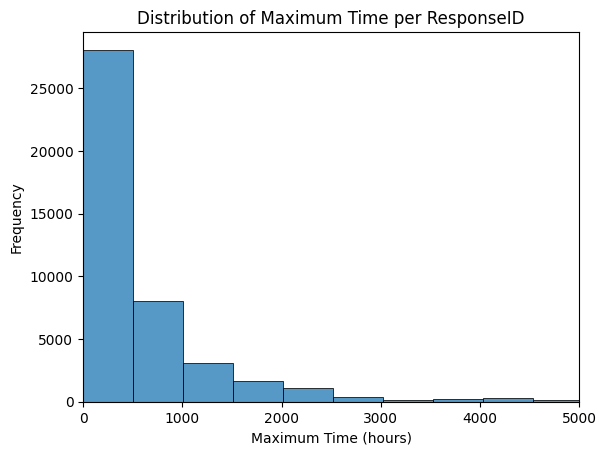

In [21]:
sns.histplot(test, binwidth=500)
plt.xlim(0, 5000)
plt.title('Distribution of Maximum Time per ResponseID')
plt.xlabel('Maximum Time (hours)')
plt.ylabel('Frequency')

From the graph above, the majority of the samples have a max time under 1000h. 
Only those samples will be used for the analysis. The rest will be considered 
outliers and removed from the dataset.

## Clean the dataset

### Functions

In [22]:
def select_dataset(df, min_time_threshold=5, max_time_threshold=504):
    # Remove data points where the maximum time exceeds a certain treshold
    filtered_df = df[(df['TObs'] >= min_time_threshold) & (df['TObs'] <= max_time_threshold)]

    return filtered_df

In [50]:
def clean_data(df, min_time_threshold=5, max_time_threshold=504, min_temp_threshold=0, max_temp_threshold=30):
    # Remove data points where the maximum time exceeds a certain treshold
    df = df[(df['TObs'] >= min_time_threshold) & (df['TObs'] <= max_time_threshold)]

    # Remove data points where the temperature is outside a certain treshold
    df = df[(df['Temperature'] >= min_temp_threshold) & (df['Temperature'] <= max_temp_threshold)]

    # Keep data from specific matrices only
    food_matrices = ['beef', 'poultry', 'produce', 'seafood', 'pork']
    df = df[df['MatrixID'].isin(food_matrices)].reset_index()

    # Fill missing values in the DataFrame based on the provided fill_values
    # dictionary
    fill_values = {
        #'n2': 78.1,         # Must calculate the O2 and CO2 value too...
        'Temperature': 21,
        #'pH':,              # Use mean value from the in_on group
        #'Aw':,              # Use mean value from the in_on group
        #'pressure': 0.101325,
        #'acetic_acid':0,
        #'alta':0,
        #'apple_polyphenol':0,
        #'ascorbic_acid':0,
        #'benzoic_acid':0,
        #'betaine':0,
        #'calcium_propionate':0,
        #'carvacrol':0,
        #'chitosan':0,
        #'cinnamaldehyde':0,
        #'citric_acid':0,
        #'clo2':0,
        #'co2':0.04,         # Must calculate the O2 and N2 value too...
        #'dextrose':0,
        #'diacetic_acid':0,
        #'edta':0,
        #'erythorbate':0,
        #'ethanol':0,
        #'fat':,             # Use mean value from the in_on group or drop
        #'fructose':0,
        #'garlic':0,
        #'glucose':0,
        #'glycerol':0,
        #'green_tea_leaf':0,
        #'green_tea_polyphenol':0,
        #'hcl':0,
        #'irradiated':0,
        #'irradiation':0,
        #'kcl':0,
        #'lactic_acid':0,
        #'lauricidin':0,
        #'malic_acid':0,
        #'moisture':,        # Use mean value from the in_on group
        #'nacl':,            # Use mean value from the in_on group
        #'nitrate':0,
        #'nitrite':0,
        #'o2':21,              # Must calculate the N2 and CO2 value too...
        #'oregano':0,
        #'pomegranate':0,
        #'potassium_lactate':0,
        #'potassium_sorbate':0,
        #'propionic_acid':0,
        #'propylene_oxide':0,
        #'protein':,         # Use mean value from the in_on group or drop
        #'rosemary':0,
        #'sodium_lactate':0,
        #'sorbic_acid':0,
        #'sucrose':0,
        #'sugar':0,
        #'thymol':0
        'PropertyID': 'Other'
    }

    # Impute missing values for 'MethodID' with the most frequent value
    imputer = SimpleImputer(missing_values=np.nan,
                            strategy='most_frequent')
    imputer.fit(df[['MethodID']])
    df['MethodID'] = imputer.transform(df[['MethodID']]).ravel()

    # Drop columns that are not needed for the analysis.
    columns_to_drop = ['Spec_rate', 'RateMethod', 'Logc0', 'CombaseID_x',
                       'heated', 'OrganismSpecification', 'Comment', 'Ph', 'Aw',
                       'Value_x', 'ComBaseID_x', 'ComBaseID_y', 'UserId',
                       'Assumed', 'index', 'ExperimentID', 'LinkId', 'SourceID',
                       'MethodID']

    for column, value in fill_values.items():
        if column in df.columns:
            df[column] = df[column].fillna(value)

    # Drop columns that are not needed for the analysis
    df = df.drop(columns=columns_to_drop, errors='ignore')

    return df

In [24]:
# Calculate co2, O2 and N2 values based on the pressure and the other gas values
def fill_gas_values(row):
    # for each empty co2 value, calculate the co2 value based on the pressure
    # and the other gas values. Do the same for o2 and n2. If all three are
    # empty, use the default values of 0.04 for co2, 21 for o2 and 78.1 for n2

    # Default values
    default_co2 = 0.04
    default_o2 = 21
    default_n2 = 78.1

    # Check if all gases are missing
    if pd.isna(row['co2']) and pd.isna(row['O2']) and pd.isna(row['N2']):
        row['co2'] = default_co2
        row['o2'] = default_o2
        row['n2'] = default_n2
    else:
        # Calculate co2, o2, n2 based on pressure or other values
        # In this case, we'll assume some linear relation for the sake of simplicity.

        # If co2 is missing, calculate based on pressure or other values
        if pd.isna(row['co2']):
            row['co2'] = (100 - row['n2'] - row['o2']) * default_co2

        # If o2 is missing, calculate based on pressure or other values
        if pd.isna(row['o2']):
            row['o2'] = (100 - row['n2'] - row['co2']) * default_o2

        # If n2 is missing, calculate based on pressure or other values
        if pd.isna(row['n2']):
            row['n2'] = (100 - row['o2'] - row['co2']) * default_n2

    return row

### Explanations

Import and merge the data...

In [25]:
data_merged['MatrixID'].value_counts()

NameError: name 'data_merged' is not defined

Since we want to predict food contamination, we should remove the data from
culture medium and keep only ['beef', 'poultry', 'produce', 'seafood', 'pork']. 
'other/mix' could be kept but it seems too undefined...

In [ ]:
# Remove data for everything but ['beef', 'poultry', 'produce', 'seafood', 'pork']
food_matrices = ['beef', 'poultry', 'produce', 'seafood', 'pork']
filtered_data = data_merged[data_merged['MatrixID'].isin(food_matrices)].reset_index()

In [ ]:
# Quantity of samples per matrix
filtered_data.groupby('MatrixID')['ResponseID'].nunique()

MatrixID
beef       1935
pork       1053
poultry    1997
produce    1424
seafood    1090
Name: ResponseID, dtype: int64

In [ ]:
# Quantity of samples per matrix
filtered_data.groupby('MatrixID')['ResponseID'].nunique()

MatrixID
beef       1935
pork       1053
poultry    1997
produce    1424
seafood    1090
Name: ResponseID, dtype: int64

In [ ]:
filtered_data

,index,ResponseID,ExperimentID,Spec_rate,RateMethod,MethodID,OrganismID,OrganismSpecification,Comment,Logc0,...,Temperature,LinkId,UserId,PropertyID,Value_x,ComBaseID_x,ID,Time,Value_y,ComBaseID_y
0,1616,43334,179.0,0.1043,NaN,plate_count,lm,NaN,Aerobic,NaN,...,10.0,ADRIAN_07,NaN,NaN,NaN,NaN,2525,0.0,3.39,ADRIAN_07
1,1617,43334,179.0,0.1043,NaN,plate_count,lm,NaN,Aerobic,NaN,...,10.0,ADRIAN_07,NaN,NaN,NaN,NaN,2526,24.0,4.99,ADRIAN_07
2,1618,43334,179.0,0.1043,NaN,plate_count,lm,NaN,Aerobic,NaN,...,10.0,ADRIAN_07,NaN,NaN,NaN,NaN,2527,31.0,4.33,ADRIAN_07
3,1619,43334,179.0,0.1043,NaN,plate_count,lm,NaN,Aerobic,NaN,...,10.0,ADRIAN_07,NaN,NaN,NaN,NaN,2528,48.0,4.77,ADRIAN_07
4,1620,43334,179.0,0.1043,NaN,plate_count,lm,NaN,Aerobic,NaN,...,10.0,ADRIAN_07,NaN,NaN,NaN,NaN,2529,55.0,5.71,ADRIAN_07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76828,273482,60254,52374.0,NaN,NaN,mpn,ss,Species: S. Newport,NaN,NaN,...,38.0,Sn_Cu_38C_2,NaN,NaN,NaN,NaN,418125,7.0,5.16,Sn_Cu_38C_2
76829,273483,60255,52375.0,NaN,NaN,mpn,ss,Species: S. Newport,NaN,NaN,...,38.0,Sn_Cu_38C_3,NaN,NaN,NaN,NaN,418126,1.0,1.25,Sn_Cu_38C_3
76830,273484,60255,52375.0,NaN,NaN,mpn,ss,Species: S. Newport,NaN,NaN,...,38.0,Sn_Cu_38C_3,NaN,NaN,NaN,NaN,418127,3.0,3.09,Sn_Cu_38C_3
76831,273485,60255,52375.0,NaN,NaN,mpn,ss,Species: S. Newport,NaN,NaN,...,38.0,Sn_Cu_38C_3,NaN,NaN,NaN,NaN,418128,5.0,4.67,Sn_Cu_38C_3


In [ ]:
filtered_data.shape

(76833, 28)

In [ ]:
# Determine the number of missing values in each column
filtered_data.isnull().sum().to_dict()

{'index': 0,
 'ResponseID': 0,
 'ExperimentID': 0,
 'Spec_rate': 60653,
 'RateMethod': 76833,
 'MethodID': 224,
 'OrganismID': 0,
 'OrganismSpecification': 21310,
 'Comment': 63028,
 'Logc0': 76833,
 'LogcVar': 0,
 'TObs': 0,
 'Assumed': 59399,
 'SourceID': 0,
 'MatrixID': 0,
 'In_on': 0,
 'Ph': 37355,
 'Aw': 49512,
 'Temperature': 0,
 'LinkId': 0,
 'UserId': 76833,
 'PropertyID': 22515,
 'Value_x': 74546,
 'ComBaseID_x': 22515,
 'ID': 0,
 'Time': 0,
 'Value_y': 0,
 'ComBaseID_y': 0}

In [ ]:
# Columns to drop
columns_to_drop = ['Spec_rate', 'RateMethod', 'Logc0', 'CombaseID_x', 'heated',
                   'OrganismSpecification', 'Comment', 'pH', 'Aw', 'Value_x',
                   'CombaseID_x', 'CombaseID_y']

In [ ]:
filtered_data['MethodID'].unique()

array(['plate_count', 'mpn', nan], dtype=object)

Default values for every conditions (replace NA by...). This includes the columns from 'Experiment Conditions' that I decided to remove for now

In [ ]:
fill_values = {
    #'n2': 78.1,         # Must calculate the O2 and CO2 value too...
    'Temperature': 22,
    #'pH':,              # Use mean value from the in_on group
    #'Aw':,              # Use mean value from the in_on group
    #'pressure': 0.101325,
    #'acetic_acid':0,
    #'alta':0,
    #'apple_polyphenol':0,
    #'ascorbic_acid':0,
    #'benzoic_acid':0,
    #'betaine':0,
    #'calcium_propionate':0,
    #'carvacrol':0,
    #'chitosan':0,
    #'cinnamaldehyde':0,
    #'citric_acid':0,
    #'clo2':0,
    #'co2':0.04,         # Must calculate the O2 and N2 value too...
    #'dextrose':0,
    #'diacetic_acid':0,
    #'edta':0,
    #'erythorbate':0,
    #'ethanol':0,
    #'fat':,             # Use mean value from the in_on group or drop
    #'fructose':0,
    #'garlic':0,
    #'glucose':0,
    #'glycerol':0,
    #'green_tea_leaf':0,
    #'green_tea_polyphenol':0,
    #'hcl':0,
    #'irradiated':0,
    #'irradiation':0,
    #'kcl':0,
    #'lactic_acid':0,
    #'lauricidin':0,
    #'malic_acid':0,
    #'moisture':,        # Use mean value from the in_on group
    #'nacl':,            # Use mean value from the in_on group
    #'nitrate':0,
    #'nitrite':0,
    #'o2':21,              # Must calculate the N2 and CO2 value too...
    #'oregano':0,
    #'pomegranate':0,
    #'potassium_lactate':0,
    #'potassium_sorbate':0,
    #'propionic_acid':0,
    #'propylene_oxide':0,
    #'protein':,         # Use mean value from the in_on group or drop
    #'rosemary':0,
    #'sodium_lactate':0,
    #'sorbic_acid':0,
    #'sucrose':0,
    #'sugar':0,
    #'thymol':0
    'PropertyID': 'Other'
}

## Final dataframe!!

In [26]:
conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source = import_data()

In [27]:
data_merged = merge_data(conditions, experiment_conditions, experiments, logcs, properties, response_properties, responses, source)

In [28]:
data_merged

,ResponseID,ExperimentID,Spec_rate,RateMethod,MethodID,OrganismID,OrganismSpecification,Comment,Logc0,LogcVar,...,Temperature,LinkId,UserId,PropertyID,Value_x,ComBaseID_x,ID,Time,Value_y,ComBaseID_y
0,38694,39472.0,0.01713,NaN,plate_count,ah,Strain(s): CECT-398,NaN,NaN,4.71,...,1.5,A_1,NaN,NaN,NaN,NaN,1,0.00,4.02,A_1
1,38694,39472.0,0.01713,NaN,plate_count,ah,Strain(s): CECT-398,NaN,NaN,4.71,...,1.5,A_1,NaN,NaN,NaN,NaN,2,22.50,3.99,A_1
2,38694,39472.0,0.01713,NaN,plate_count,ah,Strain(s): CECT-398,NaN,NaN,4.71,...,1.5,A_1,NaN,NaN,NaN,NaN,3,97.75,3.94,A_1
3,38694,39472.0,0.01713,NaN,plate_count,ah,Strain(s): CECT-398,NaN,NaN,4.71,...,1.5,A_1,NaN,NaN,NaN,NaN,4,117.50,3.92,A_1
4,38694,39472.0,0.01713,NaN,plate_count,ah,Strain(s): CECT-398,NaN,NaN,4.71,...,1.5,A_1,NaN,NaN,NaN,NaN,5,144.25,3.78,A_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484891,60418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,419495,6.50,5.43,Lm_paneer_40C_T2
484892,60418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,419496,17.00,6.70,Lm_paneer_40C_T2
484893,60418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,419497,21.00,7.51,Lm_paneer_40C_T2
484894,60418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,419498,24.00,7.79,Lm_paneer_40C_T2


In [29]:
cleaned_data = clean_data(data_merged,
                          min_time_threshold=5,
                          max_time_threshold=504,
                          min_temp_threshold=0,
                          max_temp_threshold=30)

In [30]:
cleaned_data

,ResponseID,MethodID,OrganismID,LogcVar,TObs,MatrixID,In_on,Temperature,PropertyID,ID,Time,Value_y
0,43334,plate_count,lm,7.00,360.0,beef,ground beef,10.0,Other,2525,0.0,3.39
1,43334,plate_count,lm,7.00,360.0,beef,ground beef,10.0,Other,2526,24.0,4.99
2,43334,plate_count,lm,7.00,360.0,beef,ground beef,10.0,Other,2527,31.0,4.33
3,43334,plate_count,lm,7.00,360.0,beef,ground beef,10.0,Other,2528,48.0,4.77
4,43334,plate_count,lm,7.00,360.0,beef,ground beef,10.0,Other,2529,55.0,5.71
...,...,...,...,...,...,...,...,...,...,...,...,...
53247,60240,mpn,ss,2.73,7.0,poultry,cucumber,30.0,Other,418101,7.0,3.81
53248,60241,mpn,ss,3.13,7.0,poultry,cucumber,30.0,Other,418102,1.0,1.09
53249,60241,mpn,ss,3.13,7.0,poultry,cucumber,30.0,Other,418103,3.0,1.82
53250,60241,mpn,ss,3.13,7.0,poultry,cucumber,30.0,Other,418104,5.0,2.75


In [31]:
cleaned_data.shape

(53252, 12)

In [32]:
cleaned_data.groupby('MatrixID')[['Time', 'Temperature']].describe()

Time                                                           \
            count        mean         std  min   25%   50%     75%     max   
MatrixID                                                                     
beef      11931.0   73.282537  101.361532  0.0   5.0  24.0  101.00   504.0   
pork       6250.0  127.774439  119.334509  0.0  24.0  96.0  192.00  1200.0   
poultry   12744.0   70.119772   99.115343  0.0   4.1  22.0   96.00   504.0   
produce   10424.0   93.381910  104.237104  0.0   8.0  62.5  144.00  1344.0   
seafood   11903.0  113.414530  112.311828  0.0  24.0  73.0  168.07   648.0   

         Temperature                                                   
               count       mean       std  min  25%   50%   75%   max  
MatrixID                                                               
beef         11931.0   8.897913  6.601078  0.0  5.0   5.0  11.0  30.0  
pork          6250.0   9.984976  6.880526  0.7  6.4   7.0  12.0  30.0  
poultry      12744.0  16.286307  8.726733  0.0  8.0  15.0  25.0  30.0  
produce      10424.0  14.536838  8.301574  1.0  8.0  10.0  25.0  30.0  
seafood      11903.0   8.967848  7.024496  0.0  4.0   8.0  15.0  30.0

The temperature range we are going to keep is between -22 and 30C

In [33]:
selected_data = cleaned_data[(cleaned_data['Temperature'] >= 0) & (cleaned_data['Temperature'] <= 30)]

In [34]:
selected_data.groupby('Temperature')[['Time']].describe()

Time                                                          
              count        mean         std  min    25%    50%    75%     max
Temperature                                                                  
0.0          2599.0  136.493267  119.952264  0.0   21.0  119.0  225.0  504.00
0.7            72.0  193.833333  116.209015  0.0  114.0  180.0  258.0  406.00
1.0           711.0  199.426160  118.331820  0.0   96.0  216.0  312.0  384.00
2.0           523.0  132.272562  116.750354  0.0   46.8   96.0  192.0  504.00
2.3            12.0  190.416667  133.628697  0.0   80.0  187.5  305.0  400.00
...             ...         ...         ...  ...    ...    ...    ...     ...
27.5           25.0   77.600000   72.472983  0.0    4.0   48.0  144.0  192.00
27.9           18.0   37.027778   31.940994  0.0   13.0   30.0   51.0   99.75
28.0         1044.0   13.373611   22.991245  0.0    2.3    6.0   12.0  266.50
29.4          120.0    9.850000    6.775698  0.0    4.0    8.5   16.0   21.00
30.0         1663.0   20.764191   36.168308  0.0    2.8    7.0   24.0  336.00

[84 rows x 8 columns]

Text(0, 0.5, 'Frequency')

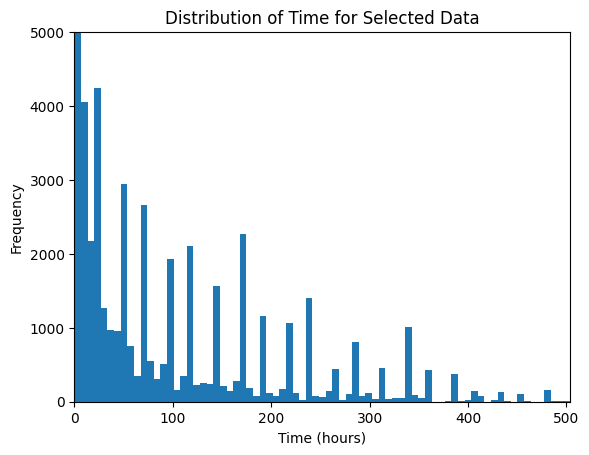

In [35]:
plt.hist(selected_data['Time'], bins=200)
plt.xlim(0, 504)
plt.ylim(0, 5000)
plt.title('Distribution of Time for Selected Data')
plt.xlabel('Time (hours)')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

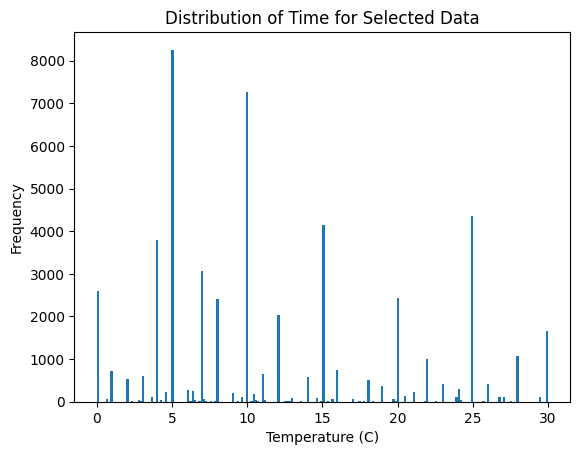

In [36]:
plt.hist(selected_data['Temperature'], bins=200)
plt.title('Distribution of Time for Selected Data')
plt.xlabel('Temperature (C)')
plt.ylabel('Frequency')

In [37]:
cleaned_data.isna().sum()

ResponseID     0
MethodID       0
OrganismID     0
LogcVar        0
TObs           0
MatrixID       0
In_on          0
Temperature    0
PropertyID     0
ID             0
Time           0
Value_y        0
dtype: int64

## Split the dataset

In [38]:
y = cleaned_data['Value_y']
X = cleaned_data.drop(columns=['Value_y'])

# Data Engineering for lagtime and other variables

In [39]:
def data_engineering(df):
    # Calculate time diff for each ResponseID from T0
    df['Time_diff'] = df['Time'] - df.groupby('ResponseID')['Time'].transform('min')

    # Calculate log diff for each ResponseID from T0
    df['log_diff'] = df['Value_y'] - df.groupby('ResponseID')['Value_y'].transform('min')

    return df

In [40]:
cleaned_data = data_engineering(cleaned_data)

In [41]:
cleaned_data

,ResponseID,MethodID,OrganismID,LogcVar,TObs,MatrixID,In_on,Temperature,PropertyID,ID,Time,Value_y,Time_diff,log_diff
0,43334,plate_count,lm,7.00,360.0,beef,ground beef,10.0,Other,2525,0.0,3.39,0.0,0.00
1,43334,plate_count,lm,7.00,360.0,beef,ground beef,10.0,Other,2526,24.0,4.99,24.0,1.60
2,43334,plate_count,lm,7.00,360.0,beef,ground beef,10.0,Other,2527,31.0,4.33,31.0,0.94
3,43334,plate_count,lm,7.00,360.0,beef,ground beef,10.0,Other,2528,48.0,4.77,48.0,1.38
4,43334,plate_count,lm,7.00,360.0,beef,ground beef,10.0,Other,2529,55.0,5.71,55.0,2.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53247,60240,mpn,ss,2.73,7.0,poultry,cucumber,30.0,Other,418101,7.0,3.81,6.0,2.73
53248,60241,mpn,ss,3.13,7.0,poultry,cucumber,30.0,Other,418102,1.0,1.09,0.0,0.00
53249,60241,mpn,ss,3.13,7.0,poultry,cucumber,30.0,Other,418103,3.0,1.82,2.0,0.73
53250,60241,mpn,ss,3.13,7.0,poultry,cucumber,30.0,Other,418104,5.0,2.75,4.0,1.66


In [42]:
cleaned_data.describe()

,ResponseID,LogcVar,TObs,Temperature,ID,Time,Value_y,Time_diff,log_diff
count,53252.000000,53252.000000,53252.000000,53252.000000,53252.000000,53252.000000,53252.000000,53252.000000,53252.000000
mean,30906.306355,3.405728,206.333203,11.913094,199887.619357,91.825974,4.985672,90.759199,1.887134
std,14357.427951,2.220239,146.366448,8.270211,125609.890560,108.240066,2.251335,107.743737,1.834169
min,1.000000,-9.890000,5.400000,0.000000,2525.000000,0.000000,-0.010000,0.000000,0.000000
25%,23690.750000,2.080000,66.000000,5.000000,142248.750000,8.000000,3.380211,8.000000,0.301030
50%,28451.000000,3.470000,192.000000,10.000000,216010.500000,48.000000,4.850000,48.000000,1.330000
75%,38217.000000,4.850000,336.000000,18.000000,274746.250000,144.000000,6.660000,144.000000,3.080494
max,60241.000000,9.940000,504.000000,30.000000,418105.000000,1344.000000,11.670000,1344.000000,9.910000


In [43]:
scaler = MinMaxScaler()
cleaned_data[['Time_diff', 'log_diff']] = scaler.fit_transform(cleaned_data[['Time_diff', 'log_diff']])

In [44]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_matrix = encoder.fit_transform(cleaned_data[['MatrixID']])
encoded_matrix_df = pd.DataFrame(encoded_matrix, columns=encoder.get_feature_names_out(['MatrixID']))
cleaned_data = pd.concat([cleaned_data.reset_index(drop=True), encoded_matrix_df.reset_index(drop=True)], axis=1).drop(columns=['MatrixID'])

In [47]:
cleaned_data['OrganismID'].unique()

array(['lm', 'bc', 'cj', 'ta', 'ent', 'ec', 'psy', 'bt', 'lab', 'ps',
       'sa', 'ss', 'sp', 'sp_yeast', 'vs', 'cbn', 'cp', 'ah', 'ye', 'mi',
       'cbp', 'sf', 'pa', 'sc', 'entc', 'ea'], dtype=object)

In [49]:
cleaned_data.groupby('OrganismID')['ResponseID'].count()

OrganismID
ah            801
bc           1133
bt           3153
cbn           240
cbp           370
cj            506
cp           2529
ea             76
ec           1481
ent          2753
entc           12
lab          3823
lm          12617
mi             40
pa             12
ps           3318
psy           298
sa            150
sc             12
sf            400
sp           1308
sp_yeast      826
ss          11222
ta           5096
vs            424
ye            652
Name: ResponseID, dtype: int64

In [51]:
cleaned_data

,ResponseID,MethodID,OrganismID,LogcVar,TObs,In_on,Temperature,PropertyID,ID,Time,Value_y,Time_diff,log_diff,MatrixID_beef,MatrixID_pork,MatrixID_poultry,MatrixID_produce,MatrixID_seafood
0,43334,plate_count,lm,7.00,360.0,ground beef,10.0,Other,2525,0.0,3.39,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0
1,43334,plate_count,lm,7.00,360.0,ground beef,10.0,Other,2526,24.0,4.99,0.017857,0.161453,1.0,0.0,0.0,0.0,0.0
2,43334,plate_count,lm,7.00,360.0,ground beef,10.0,Other,2527,31.0,4.33,0.023065,0.094854,1.0,0.0,0.0,0.0,0.0
3,43334,plate_count,lm,7.00,360.0,ground beef,10.0,Other,2528,48.0,4.77,0.035714,0.139253,1.0,0.0,0.0,0.0,0.0
4,43334,plate_count,lm,7.00,360.0,ground beef,10.0,Other,2529,55.0,5.71,0.040923,0.234107,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53247,60240,mpn,ss,2.73,7.0,cucumber,30.0,Other,418101,7.0,3.81,0.004464,0.275479,0.0,0.0,1.0,0.0,0.0
53248,60241,mpn,ss,3.13,7.0,cucumber,30.0,Other,418102,1.0,1.09,0.000000,0.000000,0.0,0.0,1.0,0.0,0.0
53249,60241,mpn,ss,3.13,7.0,cucumber,30.0,Other,418103,3.0,1.82,0.001488,0.073663,0.0,0.0,1.0,0.0,0.0
53250,60241,mpn,ss,3.13,7.0,cucumber,30.0,Other,418104,5.0,2.75,0.002976,0.167508,0.0,0.0,1.0,0.0,0.0


### For JYL

In [ ]:
from ml_logic.baseline import ClassicalModel
baseline_params = ClassicalModel()

In [ ]:
baseline_params.fit(cleaned_data['Time'],cleaned_data['Value_y'], 'linear')

In [ ]:
baseline_params

In [ ]:
baseline_params.predict(cleaned_data['Time'])

0        4.562830
1        4.684726
2        4.720279
3        4.806621
4        4.842174
           ...   
52047    4.598383
52048    4.567909
52049    4.578067
52050    4.588225
52051    4.598383
Name: Time, Length: 52052, dtype: float64